In [15]:
import sys
from pathlib import Path

!pip install numpy, 
!pip install onnxruntime
!pip install matplotlib 
!pip install seaborn
!pip install tqdm

ROOT = Path.cwd()
NOTEBOOK_DIR = Path("/Users/jerryonyango/Desktop/controls-challenge/controls_challenge")

if not (ROOT / "tinyphysics.py").exists():
  sys.path.insert(0, str(NOTEBOOK_DIR))

from tinyphysics import TinyPhysicsModel, TinyPhysicsSimulator, CONTROL_START_IDX
from controllers import pid, pid_plus
from matplotlib import pyplot as plt
import seaborn as sns

sns.set_theme()

ERROR: Invalid requirement: 'numpy,'

[notice] A new release of pip is available: 23.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 23.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 23.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 23.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 23.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [20]:
def plot_rollout(sim):
  fig, ax = plt.subplots(figsize=(10, 5))
  ax.plot(sim.target_lataccel_history, label="Target Lateral Acceleration", alpha=0.5)
  ax.plot(sim.current_lataccel_history, label="Actual Lateral Acceleration", alpha=0.5)
  ax.legend()
  ax.set_xlabel("Step")
  ax.set_ylabel("Lateral Acceleration")
  ax.set_title("Rollout")
  plt.show()

In [21]:
model = TinyPhysicsModel("./models/tinyphysics.onnx", debug=True)
controller = pid_plus.Controller()

In [22]:
sim = TinyPhysicsSimulator(model, "./data/00000.csv", controller=controller, debug=False)
sim.rollout()

{'lataccel_cost': np.float64(1.1886791953333384),
 'jerk_cost': np.float64(34.62933325666021),
 'total_cost': np.float64(94.06329302332713)}

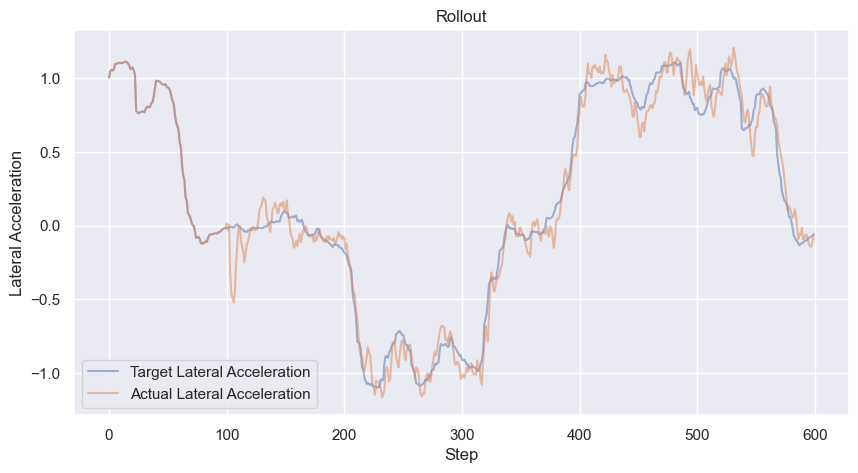

In [23]:
plot_rollout(sim)